# Functions


In [5]:
def compute_distances_no_loops(x_train: torch.Tensor, x_test: torch.Tensor):
    """
    Computes the squared Euclidean distance between each element of training
    set and each element of test set. Images should be flattened and treated
    as vectors.

    This implementation should not use any Python loops. For memory-efficiency,
    it also should not create any large intermediate tensors; in particular you
    should not create any intermediate tensors with O(num_train * num_test)
    elements.

    Similar to `compute_distances_two_loops`, this should be able to handle
    inputs with any number of dimensions. The inputs should not be modified.

    NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
    `torch.cdist`, or their instance method variants (`x.norm`, `x.dist`,
    `x.cdist`, etc.). You may not use any functions from `torch.nn` or
    `torch.nn.functional` modules.

    Args:
        x_train: Tensor of shape (num_train, C, H, W)
        x_test: Tensor of shape (num_test, C, H, W)

    Returns:
        dists: Tensor of shape (num_train, num_test) where dists[i, j] is
            the squared Euclidean distance between the i-th training point and
            the j-th test point.
    """
    # Initialize dists to be a tensor of shape (num_train, num_test) with the
    # same datatype and device as x_train
    num_train = x_train.shape[0]
    num_test = x_test.shape[0]
    dists = x_train.new_zeros(num_train, num_test)
    ##########################################################################
    # TODO: Implement this function without using any explicit loops and     #
    # without creating any intermediate tensors with O(num_train * num_test) #
    # elements.                                                              #
    #                                                                        #
    # You may not use torch.norm (or its instance method variant), nor any   #
    # functions from torch.nn or torch.nn.functional.                        #
    #                                                                        #
    # HINT: Try to formulate the Euclidean distance using two broadcast sums #
    #       and a matrix multiply.                                           #
    ##########################################################################
    # Replace "pass" statement with your code
    x_train_flat = x_train.reshape(num_train, -1)
    x_test_flat = x_test.reshape(num_test, -1)

    train_squares = torch.sum(x_train_flat ** 2, dim=1, keepdim=True)
    test_squares = torch.sum(x_test_flat ** 2, dim=1)

    cross_term = torch.mm(x_train_flat, x_test_flat.t())

    dists = train_squares - 2 * cross_term + test_squares
    ##########################################################################
    #                           END OF YOUR CODE                             #
    ##########################################################################
    return dists


In [1]:
def hello():
    """
    This is a sample function that we will try to import and run to ensure that
    our environment is correctly set up.
    """
    print("Hello from knn.py!")


In [22]:
def compute_distances_two_loops(x_train: torch.Tensor, x_test: torch.Tensor):
    """
    Computes the squared Euclidean distance between each element of training
    set and each element of test set. Images should be flattened and treated
    as vectors.

    This implementation uses a naive set of nested loops over the training and
    test data.

    The input data may have any number of dimensions -- for example this
    function should be able to compute nearest neighbor between vectors, in
    which case the inputs will have shape (num_{train, test}, D); it should
    also be able to compute nearest neighbors between images, where the inputs
    will have shape (num_{train, test}, C, H, W). More generally, the inputs
    will have shape (num_{train, test}, D1, D2, ..., Dn); you should flatten
    each element of shape (D1, D2, ..., Dn) into a vector of shape
    (D1 * D2 * ... * Dn) before computing distances.

    The input tensors should not be modified.

    NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
    `torch.cdist`, or their instance method variants (`x.norm`, `x.dist`,
    `x.cdist`, etc.). You may not use any functions from `torch.nn` or
    `torch.nn.functional` modules.

    Args:
        x_train: Tensor of shape (num_train, D1, D2, ...)
        x_test: Tensor of shape (num_test, D1, D2, ...)

    Returns:
        dists: Tensor of shape (num_train, num_test) where dists[i, j]
            is the squared Euclidean distance between the i-th training point
            and the j-th test point. It should have the same dtype as x_train.
    """
    # Initialize dists to be a tensor of shape (num_train, num_test) with the
    # same datatype and device as x_train
    num_train = x_train.shape[0]
    num_test = x_test.shape[0]
    dists = x_train.new_zeros(num_train, num_test)
    ##########################################################################
    # TODO: Implement this function using a pair of nested loops over the    #
    # training data and the test data.                                       #
    #                                                                        #
    # You may not use torch.norm (or its instance method variant), nor any   #
    # functions from torch.nn or torch.nn.functional.                        #
    ##########################################################################
    # Replace "pass" statement with your code
    x_train_flat = x_train.reshape(num_train, -1)
    x_test_flat = x_test.reshape(num_test, -1)
    for i in range(num_train):
        for j in range(num_test):
            dists[i, j] = torch.sum((x_train_flat[i] - x_test_flat[j]) ** 2)
    ##########################################################################
    #                           END OF YOUR CODE                             #
    ##########################################################################
    return dists


In [27]:
def compute_distances_one_loop(x_train: torch.Tensor, x_test: torch.Tensor):
    """
    Computes the squared Euclidean distance between each element of training
    set and each element of test set. Images should be flattened and treated
    as vectors.

    This implementation uses only a single loop over the training data.

    Similar to `compute_distances_two_loops`, this should be able to handle
    inputs with any number of dimensions. The inputs should not be modified.

    NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
    `torch.cdist`, or their instance method variants (`x.norm`, `x.dist`,
    `x.cdist`, etc.). You may not use any functions from `torch.nn` or
    `torch.nn.functional` modules.

    Args:
        x_train: Tensor of shape (num_train, D1, D2, ...)
        x_test: Tensor of shape (num_test, D1, D2, ...)

    Returns:
        dists: Tensor of shape (num_train, num_test) where dists[i, j]
            is the squared Euclidean distance between the i-th training point
            and the j-th test point. It should have the same dtype as x_train.
    """
    # Initialize dists to be a tensor of shape (num_train, num_test) with the
    # same datatype and device as x_train
    num_train = x_train.shape[0]
    num_test = x_test.shape[0]
    dists = x_train.new_zeros(num_train, num_test)
    ##########################################################################
    # TODO: Implement this function using only a single loop over x_train.   #
    #                                                                        #
    # You may not use torch.norm (or its instance method variant), nor any   #
    # functions from torch.nn or torch.nn.functional.                        #
    ##########################################################################
    # Replace "pass" statement with your code
    x_train_flat = x_train.reshape(num_train, -1)
    x_test_flat = x_test.reshape(num_test, -1)
    for i in range(num_train):
        dists[i] = torch.sum((x_train_flat[i] - x_test_flat) ** 2, dim=1)
    ##########################################################################
    #                           END OF YOUR CODE                             #
    ##########################################################################
    return dists


# IMPORTS

In [20]:
import torch
import torchvision
import matplotlib.pyplot as plt
import statistics

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['font.size'] = 16

#CIFAR. LOADING ANS SAMPLING

In [15]:
import torchvision
import torchvision.transforms as transforms

In [16]:
torch.manual_seed(0)
num_train = 5000
num_test = 500

In [17]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [29:33<00:00, 96.1kB/s]


# Visualize the dataset


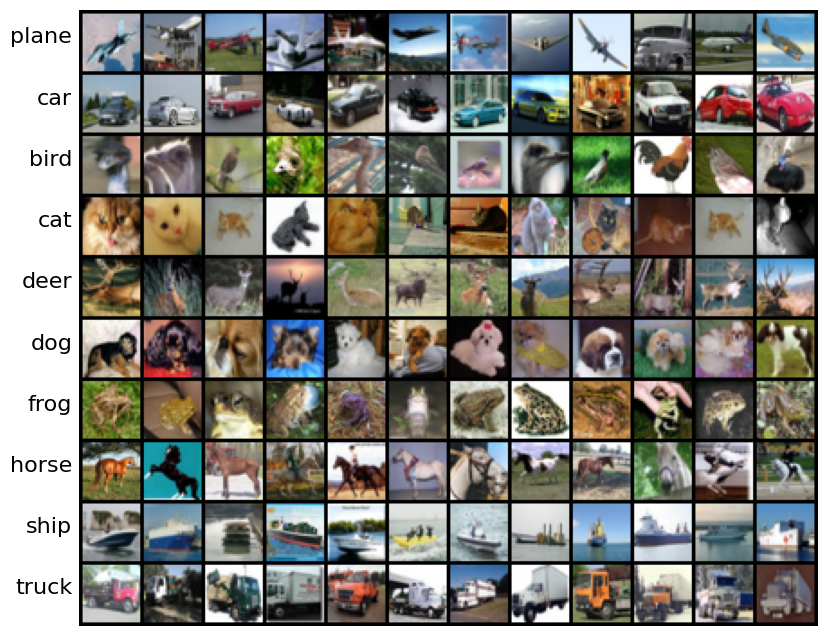

In [21]:
import random
import matplotlib.pyplot as plt
import torchvision.utils

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
samples_per_class = 12
samples = []

for y, cls in enumerate(classes):
    plt.text(-4, 34 * y + 18, cls, ha='right')
    idxs, = (y_train == y).nonzero(as_tuple=True)
    for i in range(samples_per_class):
        idx = idxs[random.randrange(idxs.shape[0])].item()
        samples.append(x_train[idx])

img = torchvision.utils.make_grid(samples, nrow=samples_per_class)

plt.imshow(img.permute(1, 2, 0))

plt.axis('off')
plt.show()

#K-Nearest Neighbors (k-NN)

Compute distances: Naive implementation

In [25]:

torch.manual_seed(0)
num_train = 500
num_test = 250

x_train = torch.stack([train_dataset[i][0] for i in range(num_train)])
x_test = torch.stack([test_dataset[i][0] for i in range(num_test)])

dists = compute_distances_two_loops(x_train, x_test)
print('dists has shape: ', dists.shape)

dists has shape:  torch.Size([500, 250])


Check the two-loop implementation

In [26]:
x_train_small = torch.tensor([[0.0, 0.0], [3.0, 4.0]], dtype=torch.float64)
x_test_small = torch.tensor([[0.0, 4.0], [3.0, 0.0]], dtype=torch.float64)
expected = torch.tensor([[16.0, 9.0], [9.0, 16.0]], dtype=torch.float64)

actual = compute_distances_two_loops(x_train_small, x_test_small)
assert actual.shape == (2, 2), f"Expected shape (2, 2), got {tuple(actual.shape)}"
assert torch.allclose(actual, expected), f"Expected {expected}, got {actual}"
print("Two-loop distance test passed.")

Two-loop distance test passed.


Compute distances: Vectorization

In [28]:
torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_one = compute_distances_one_loop(x_train_rand, x_test_rand)
dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
difference = (dists_one - dists_two).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-4:
    print('Good! The distance matrices match')
else:
    print('Uh-oh! The distance matrices are different')

Difference:  0.0
Good! The distance matrices match


In [29]:
torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
dists_none = compute_distances_no_loops(x_train_rand, x_test_rand)
difference = (dists_two - dists_none).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-10:
  print('Good! The distance matrices match')
else:
  print('Uh-oh! The distance matrices are different')

Difference:  1.7738061492165876e-11
Good! The distance matrices match


In [30]:
import time

def timeit(f, *args):
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

torch.manual_seed(0)
x_train_rand = torch.randn(500, 3, 32, 32)
x_test_rand = torch.randn(500, 3, 32, 32)

two_loop_time = timeit(compute_distances_two_loops, x_train_rand, x_test_rand)
print('Two loop version took %.2f seconds' % two_loop_time)

one_loop_time = timeit(compute_distances_one_loop, x_train_rand, x_test_rand)
speedup = two_loop_time / one_loop_time
print('One loop version took %.2f seconds (%.1fX speedup)'
      % (one_loop_time, speedup))

no_loop_time = timeit(compute_distances_no_loops, x_train_rand, x_test_rand)
speedup = two_loop_time / no_loop_time
print('No loop version took %.2f seconds (%.1fX speedup)'
      % (no_loop_time, speedup))

Two loop version took 8.72 seconds
One loop version took 0.81 seconds (10.7X speedup)
No loop version took 0.02 seconds (514.4X speedup)
